In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [2]:
# Load the Excel file

df = pd.read_excel("online_retail_II.xlsx")

# Display the first 5 rows
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
print(df.shape)
print(df.columns)
df.info()

(525461, 8)
Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [4]:
# Check missing values
print(df.isnull().sum())

# Remove rows with missing Customer ID
df = df.dropna(subset=["Customer ID"])

# Remove cancelled orders (Invoice starts with 'C')
df = df[~df["Invoice"].astype(str).str.startswith("C")]

# Remove negative or zero quantities
df = df[df["Quantity"] > 0]

# Remove negative or zero prices
df = df[df["Price"] > 0]

# Check new shape
print("Cleaned dataset shape:", df.shape)


Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64
Cleaned dataset shape: (407664, 8)


In [5]:
# Create Total Amount column
df["TotalAmount"] = df["Quantity"] * df["Price"]

# Display first 5 rows
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalAmount
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [6]:
country_sales = (
    df.groupby("Country")["TotalAmount"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

country_sales

Country
United Kingdom    7414755.963
EIRE               356085.210
Netherlands        268786.000
Germany            202395.321
France             146215.420
Sweden              53171.390
Denmark             50906.850
Spain               47601.420
Switzerland         43921.390
Australia           31446.800
Name: TotalAmount, dtype: float64

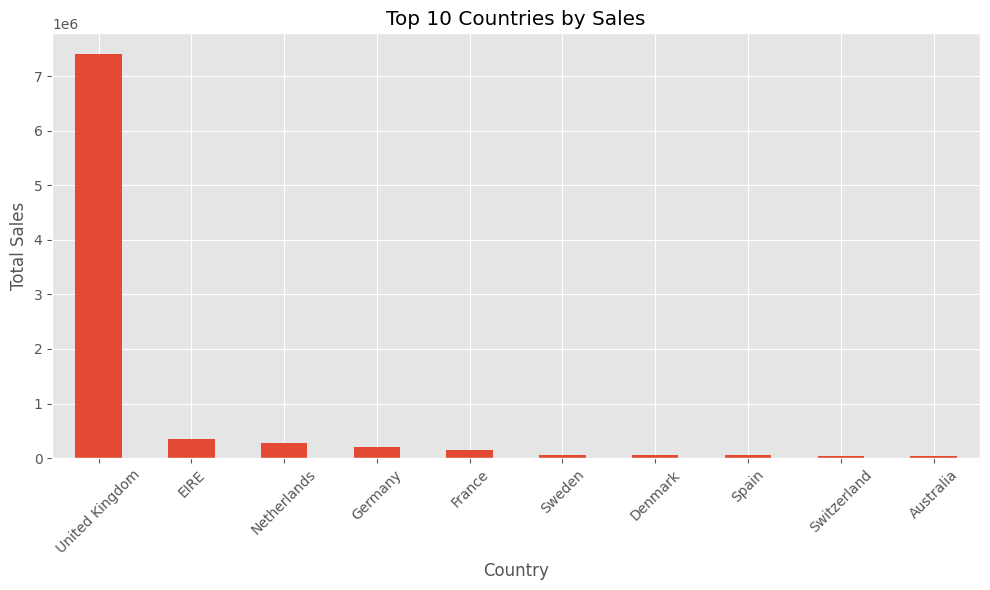

In [7]:
plt.figure(figsize=(10,6))

country_sales.plot(kind="bar")

plt.title("Top 10 Countries by Sales")
plt.xlabel("Country")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

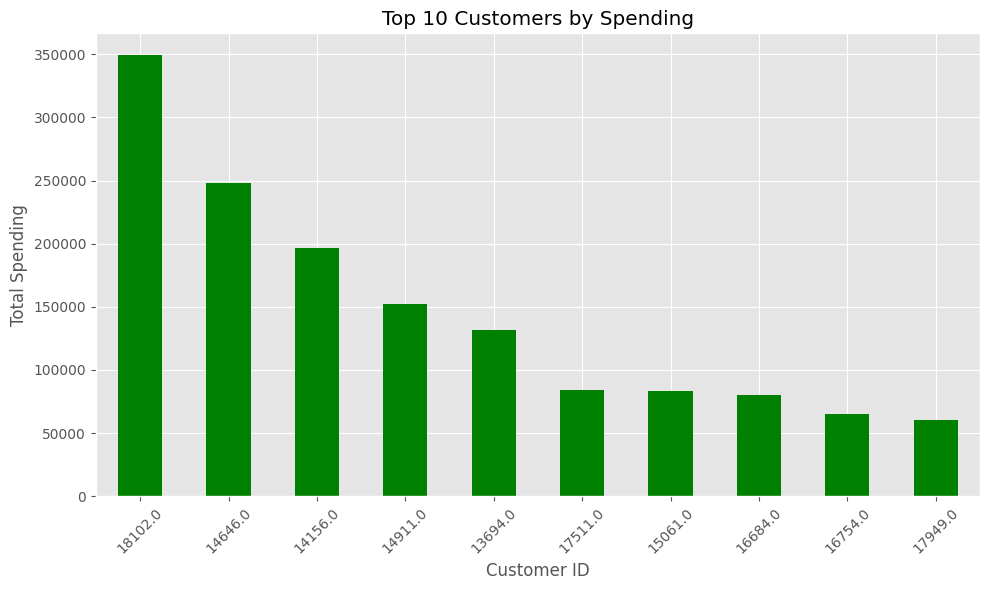

In [8]:
top_customers = (
    df.groupby("Customer ID")["TotalAmount"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))

top_customers.plot(kind="bar", color="green")

plt.title("Top 10 Customers by Spending")
plt.xlabel("Customer ID")
plt.ylabel("Total Spending")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

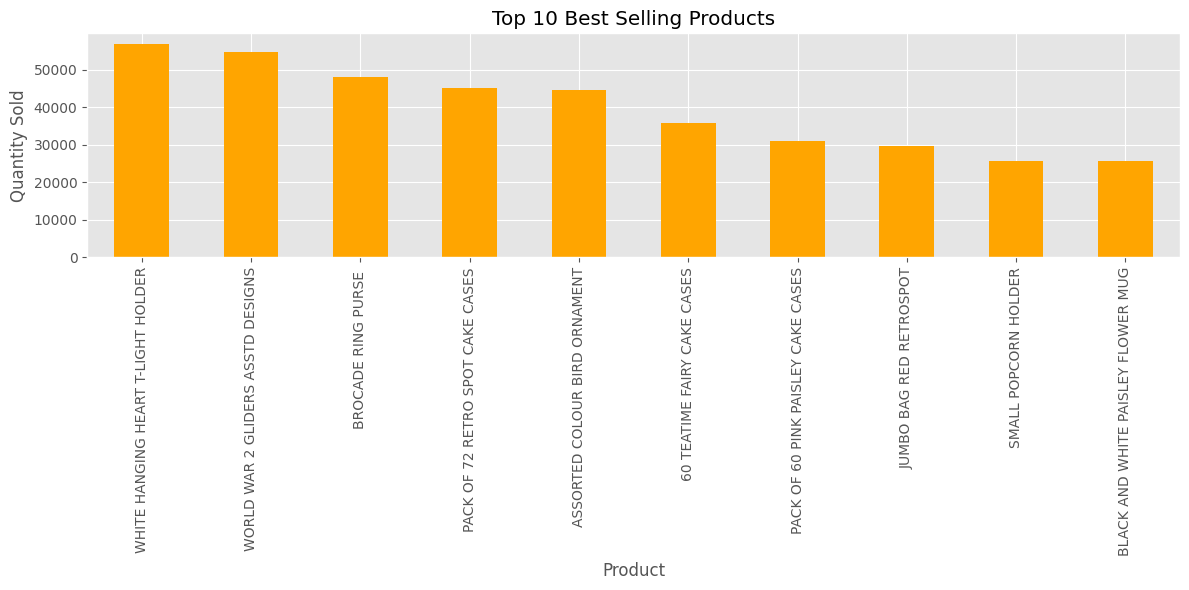

In [9]:
top_products = (
    df.groupby("Description")["Quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

top_products.plot(kind="bar", color="orange")

plt.title("Top 10 Best Selling Products")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

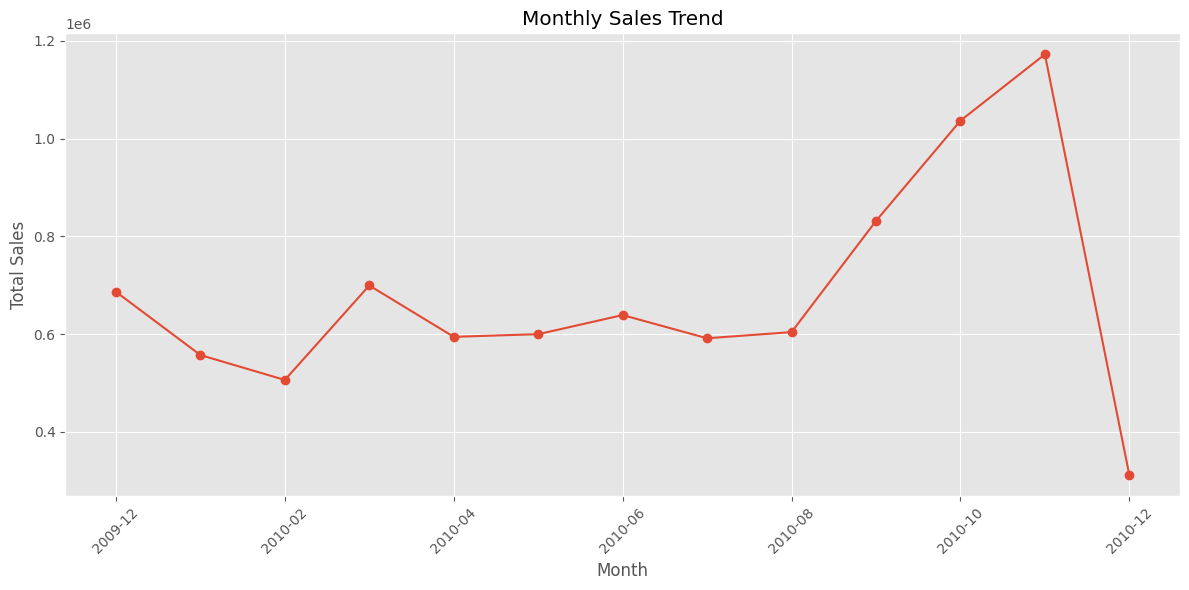

In [10]:
# Convert InvoiceDate to datetime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Create Month column
df["Month"] = df["InvoiceDate"].dt.to_period("M").astype(str)

monthly_sales = df.groupby("Month")["TotalAmount"].sum()

plt.figure(figsize=(12,6))
monthly_sales.plot(marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("monthly_sales.png")
plt.show()

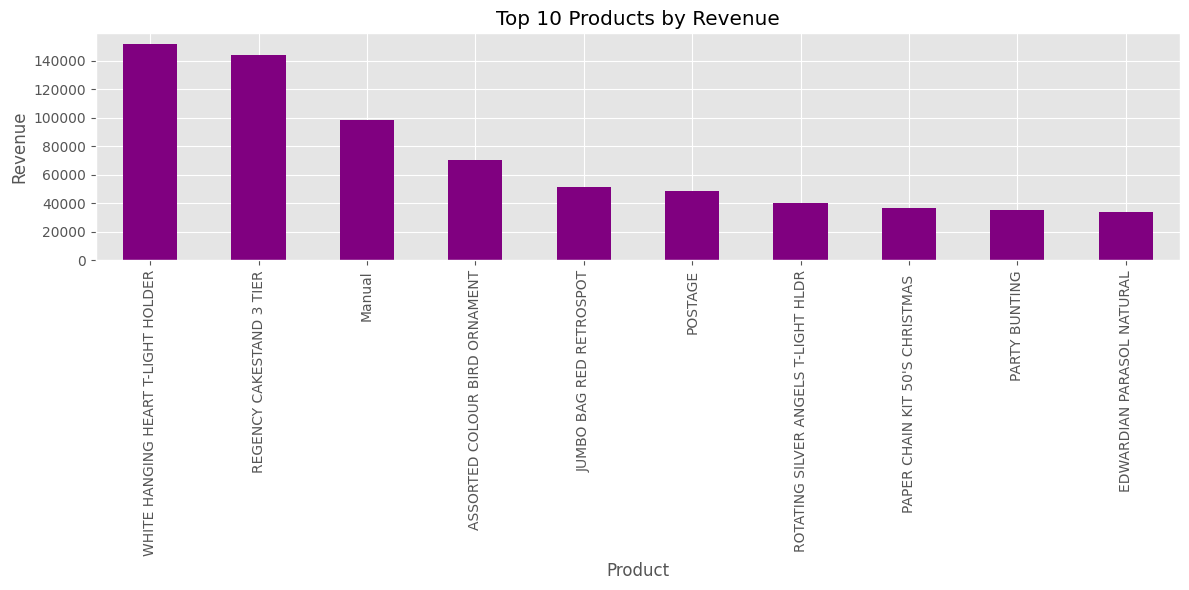

In [11]:
product_sales = (
    df.groupby("Description")["TotalAmount"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))
product_sales.plot(kind="bar", color="purple")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")

plt.xticks(rotation=90)

plt.tight_layout()
plt.savefig("top_products_revenue.png")
plt.show()

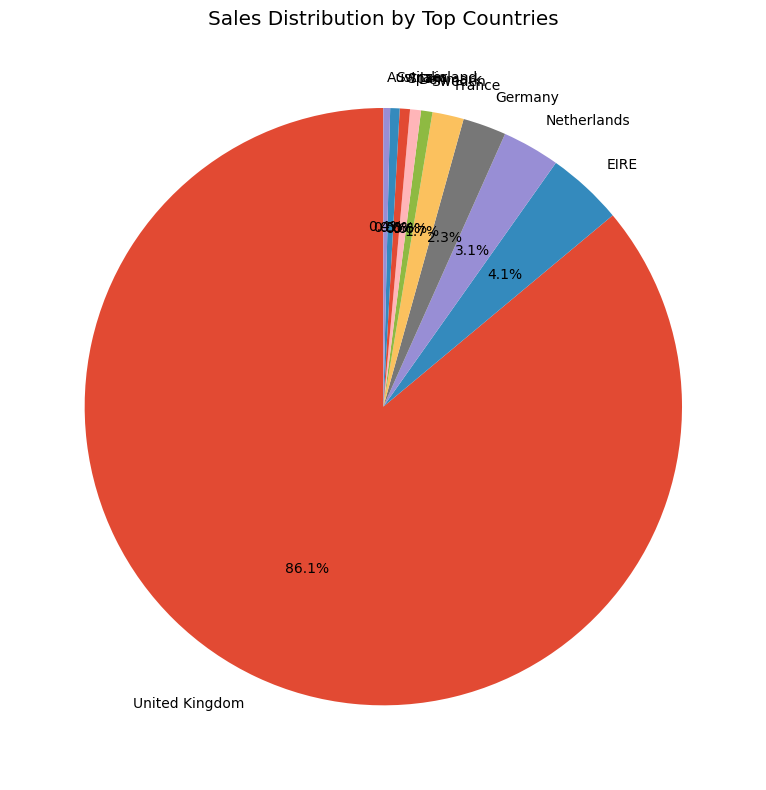

In [12]:
plt.figure(figsize=(8,8))

country_sales.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.ylabel("")
plt.title("Sales Distribution by Top Countries")

plt.tight_layout()
plt.savefig("country_sales_pie.png")
plt.show()

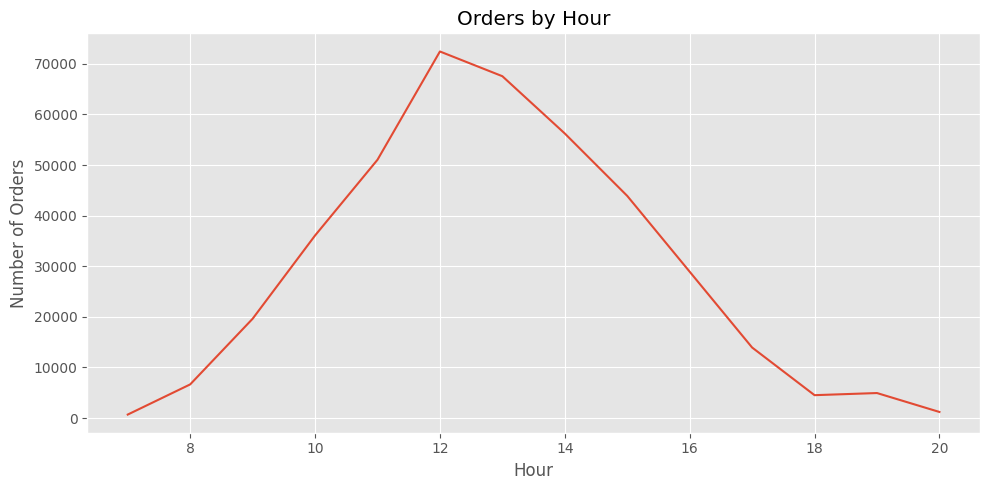

In [13]:
df["Hour"] = df["InvoiceDate"].dt.hour

hourly_orders = df.groupby("Hour").size()

plt.figure(figsize=(10,5))

hourly_orders.plot()

plt.title("Orders by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Orders")

plt.grid(True)

plt.tight_layout()
plt.savefig("orders_by_hour.png")
plt.show()

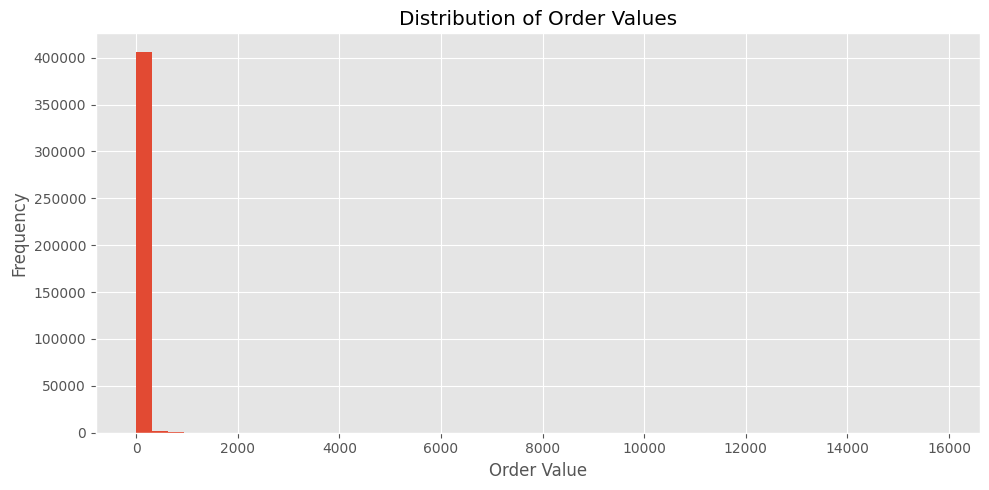

In [14]:
plt.figure(figsize=(10,5))

plt.hist(df["TotalAmount"], bins=50)

plt.title("Distribution of Order Values")
plt.xlabel("Order Value")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig("order_value_distribution.png")
plt.show()

# Business Insights

## Key Findings

- The business generated the highest revenue from a small group of loyal customers.
- The United Kingdom contributed the largest share of total sales.
- A few products accounted for a significant percentage of total revenue.
- Sales showed seasonal trends with noticeable monthly fluctuations.
- Most customer orders were relatively small, while a few large orders generated very high revenue.
- Customer purchasing activity peaked during specific hours of the day, helping identify the best marketing times.

## Recommendations

- Reward top customers through loyalty programs.
- Increase inventory for best-selling products.
- Launch promotions during high-traffic shopping hours.
- Focus marketing efforts on high-performing countries.
- Encourage larger purchases through bundle offers and discounts.

# Conclusion

This project analyzes customer purchasing behavior using Python, Pandas, and Matplotlib.

The analysis identifies valuable customers, top-selling products, monthly sales trends, country-wise sales, and customer purchasing patterns.

These insights can help businesses improve marketing strategies, inventory planning, customer retention, and overall business decision-making.